In [15]:
import pandas as pd 
import numpy as np 


data.to_csv("./latin_square_design.csv", index=False)

In [54]:
# 新しいDataFrameを複製
new_data = data.copy()

# マップ定義（すでに空白除去済のデータに適用する）
condition_id_map = {
    "空間参照だけ": 1,
    "Pointingだけ": 3,
    "Pointing+空間参照": 2,
    "ラベル": 4
}

condition_name_map = {
    "空間参照だけ": "FilterDeviceAgent + SpatialReasoningAgent",
    "Pointingだけ": "Pointing",
    "Pointing+空間参照": "Pointing + SpatialReasoningAgent",
    "ラベル": "Labeling"
}

# 条件にマッチする行を検出
mask = new_data["Free Description (自由記述)"].isin(condition_id_map.keys())

# マッピング適用
new_data.loc[mask, "ConditionID"] = new_data.loc[mask, "Free Description (自由記述)"].map(condition_id_map)
new_data.loc[mask, "ConditionName"] = new_data.loc[mask, "Free Description (自由記述)"].map(condition_name_map)

# 保存
new_data.to_csv("SurvayResult.csv", index=False, encoding="utf-8-sig")


In [3]:
new_data

NameError: name 'new_data' is not defined

In [11]:
conditions = pd.DataFrame({
 "ConditionID" : [1,2,3,4], 
 "ConditionName" : [
     "FilterDeviceAgent + SpatialReasoningAgent", 
     "Pointing + SpatialReasoningAgent", 
     "Pointing", 
     "Label",
 ]
     
})

conditions.to_csv("./condition.csv", index=False)

In [16]:
import pandas as pd

# 読み込み
df = pd.read_csv("old_latin_square_design.csv")
df.columns = df.columns.str.strip()  # 念のため空白除去

# 変換マッピング定義
condition_map = {
    "Spatial(WoZ)": "FD+SR(1)",
    "Pointing+Spatial(WoZ)": "Pointing+SR(2)",
    "Spatial(System)": "Pointing(3)",
    "Label(WoZ)": "Label(4)"
}

# 対象列一覧
condition_cols = ["Condition 1", "Condition 2", "Condition 3", "Condition 4"]

# 変換処理（各列にマッピングを適用）
for col in condition_cols:
    df[col] = df[col].map(condition_map)

# 結果表示
print(df[["Participant"] + condition_cols])

# 必要なら保存
df.to_csv("latin_square_design_converted.csv", index=False, encoding="utf-8-sig")


       Participant     Condition 1     Condition 2     Condition 3  \
0    Participant 1        FD+SR(1)     Pointing(3)  Pointing+SR(2)   
1    Participant 2  Pointing+SR(2)        FD+SR(1)        Label(4)   
2    Participant 3        Label(4)  Pointing+SR(2)     Pointing(3)   
3    Participant 4     Pointing(3)        Label(4)        FD+SR(1)   
4    Participant 5        FD+SR(1)     Pointing(3)  Pointing+SR(2)   
5    Participant 6  Pointing+SR(2)        FD+SR(1)        Label(4)   
6    Participant 7        Label(4)  Pointing+SR(2)     Pointing(3)   
7    Participant 8     Pointing(3)        Label(4)        FD+SR(1)   
8    Participant 9        FD+SR(1)     Pointing(3)  Pointing+SR(2)   
9   Participant 10  Pointing+SR(2)        FD+SR(1)        Label(4)   
10  Participant 11        Label(4)  Pointing+SR(2)     Pointing(3)   
11  Participant 12     Pointing(3)        Label(4)        FD+SR(1)   
12  Participant 13        FD+SR(1)     Pointing(3)  Pointing+SR(2)   
13  Participant 14  

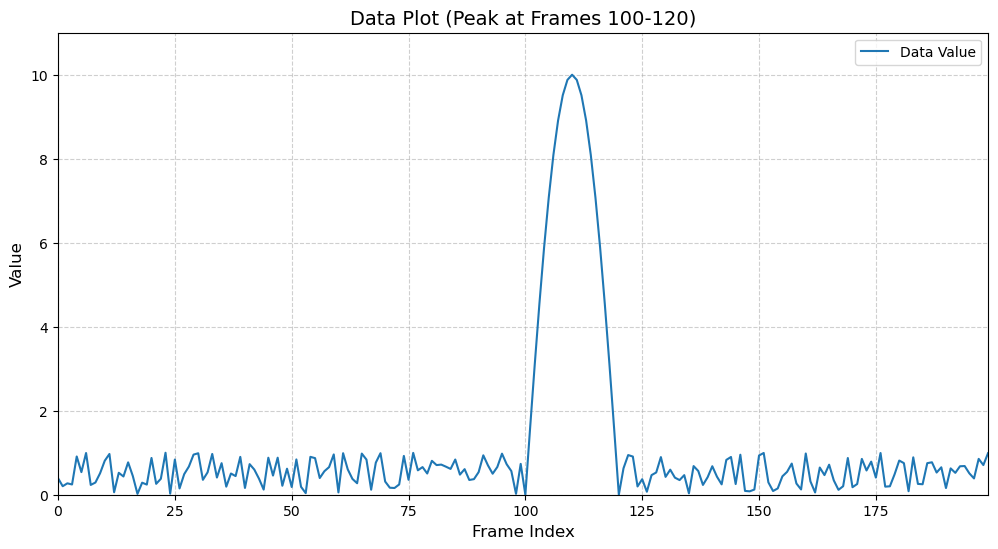

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- データ生成 ---
total_frames = 200  # 全フレーム数
peak_start = 100    # 山なりカーブの開始インデックス
peak_end = 120      # 山なりカーブの終了インデックス
peak_value = 10     # 山の頂点の値

# 1. 200フレームすべてを 0.0 ～ 1.0 のランダムな値で初期化
frames = np.random.rand(total_frames)

# 2. 山なりカーブ（100～120）を生成
# 山なりの長さを計算 (peak_end を含むため +1)
mountain_length = peak_end - peak_start + 1

# 0 から pi (約3.14) までの値を (mountain_length) 個に等分割
# これにより sin(0)=0, sin(pi/2)=1, sin(pi)=0 というカーブを作れる
x_linear = np.linspace(0, np.pi, mountain_length)

# sinカーブを計算し、peak_value（10）を掛ける
mountain_curve = peak_value * np.sin(x_linear)

# 3. 配列の [100:121] の部分を、生成した山なりカーブで上書き
# スライスは [start : end + 1] となります
frames[peak_start : peak_end + 1] = mountain_curve

# --- グラフのプロット ---
plt.figure(figsize=(12, 6))
plt.plot(frames, label='Data Value')

# タイトルとラベルを追加
plt.title('Data Plot (Peak at Frames 100-120)', fontsize=14)
plt.xlabel('Frame Index', fontsize=12)
plt.ylabel('Value', fontsize=12)

# グリッドを表示
plt.grid(True, linestyle='--', alpha=0.6)

# y軸の範囲を調整（山の頂点(10)が切れないように）
plt.ylim(0, peak_value + 1) # 0から11までの範囲

# x軸の範囲
plt.xlim(0, total_frames - 1)

# 凡例を表示
plt.legend()

# グラフを画像ファイルとして保存
# （注：このコードを実行環境で実行するとファイルが保存されます）
file_name = 'frames_data_plot.png'
plt.savefig(file_name, dpi=150, bbox_inches='tight')

# print(f"Graph saved as '{file_name}'")

FFTスペクトルのグラフを 'fft_plot.png' として保存しました。


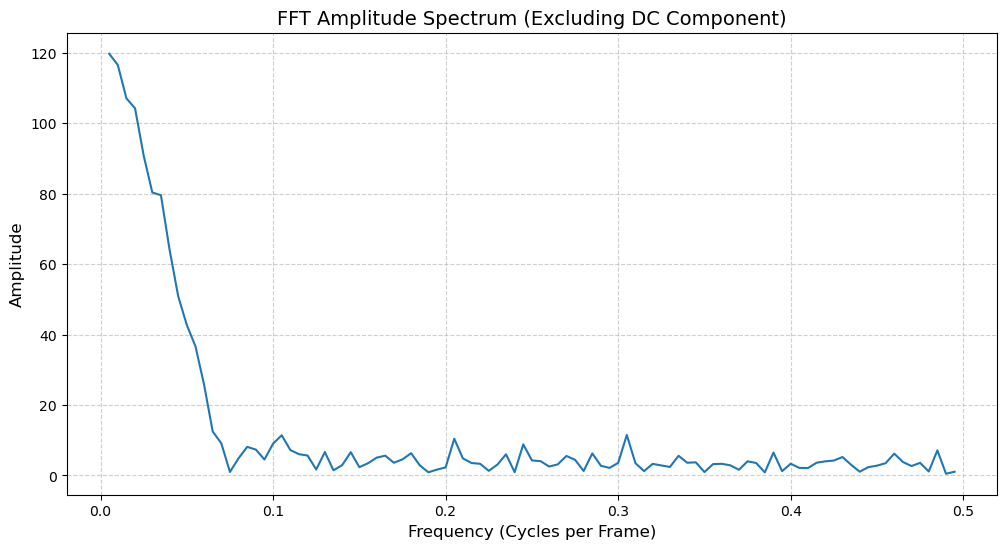

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 元データの生成（前回と同じ） ---
total_frames = 200  # 全フレーム数
peak_start = 100    # 山なりカーブの開始インデックス
peak_end = 120      # 山なりカーブの終了インデックス
peak_value = 10     # 山の頂点の値

# 1-1. 200フレームすべてを 0.0 ～ 1.0 のランダムな値で初期化
frames = np.random.rand(total_frames)

# 1-2. 山なりカーブ（100～120）を生成
mountain_length = peak_end - peak_start + 1
x_linear = np.linspace(0, np.pi, mountain_length)
mountain_curve = peak_value * np.sin(x_linear)

# 1-3. 配列の [100:121] の部分を、生成した山なりカーブで上書き
frames[peak_start : peak_end + 1] = mountain_curve


# --- 2. FFT（高速フーリエ変換）の実行 ---

N = total_frames  # サンプル数（総フレーム数）

# 2-1. FFTを実行
# 結果は複素数の配列 (complex number)
fft_result = np.fft.fft(frames)

# 2-2. 周波数軸を計算
# d=1.0 はサンプリング間隔（1フレーム=1.0と仮定）
# 結果の配列の前半 N//2 個分（正の周波数領域）を取得
frequencies = np.fft.fftfreq(N, d=1.0)[:N//2]

# 2-3. 振幅スペクトルを計算
# 複素数の絶対値 np.abs() を取る
# 結果の配列の前半 N//2 個分を取得
amplitudes = np.abs(fft_result)[:N//2]


# --- 3. FFT結果のグラフ描画 ---
plt.figure(figsize=(12, 6))

# 3-1. 振幅スペクトルをプロット
# amplitudes[0] は 0Hz 成分 (直流成分) で、非常に値が大きいため、
# それを除外した [1:] の範囲をプロットして変化を見やすくします。
plt.plot(frequencies[1:], amplitudes[1:])

# 3-2. グラフのタイトルとラベル
plt.title('FFT Amplitude Spectrum (Excluding DC Component)', fontsize=14)
plt.xlabel('Frequency (Cycles per Frame)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)

# 3-3. グリッドと保存
plt.grid(True, linestyle='--', alpha=0.6)
file_name = 'fft_plot.png'
plt.savefig(file_name, dpi=150, bbox_inches='tight')

print(f"FFTスペクトルのグラフを '{file_name}' として保存しました。")

フィルタ後の信号グラフを 'filtered_signal_plot.png' として保存しました。
フィルタ後のFFTグラフを 'filtered_fft_plot.png' として保存しました。


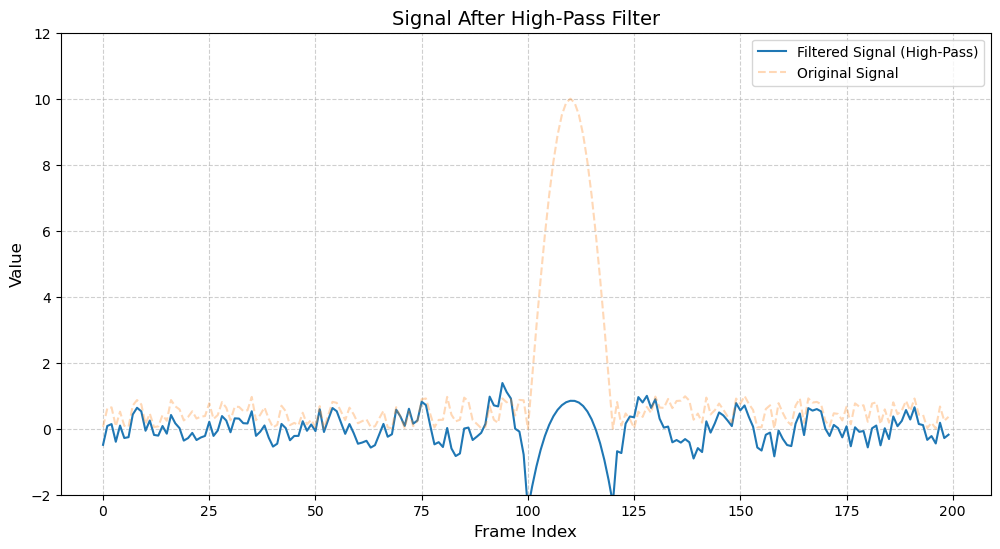

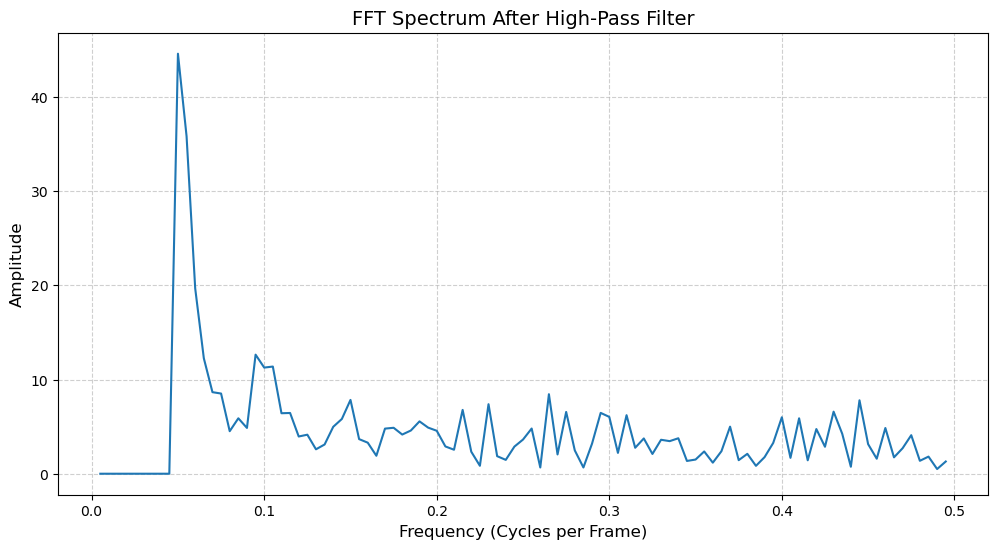

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 元データの生成（前回と同じ） ---
total_frames = 200
peak_start = 100
peak_end = 120
peak_value = 10

frames = np.random.rand(total_frames)
mountain_length = peak_end - peak_start + 1
x_linear = np.linspace(0, np.pi, mountain_length)
mountain_curve = peak_value * np.sin(x_linear)
frames[peak_start : peak_end + 1] = mountain_curve
N = total_frames

# --- 2. FFTの実行とハイパスフィルタの適用 ---

# 2-1. FFTを実行
fft_result = np.fft.fft(frames)

# 2-2. 周波数軸を取得 (ifftのために N 個すべて取得)
# d=1.0 はサンプリング間隔 (1フレーム=1.0)
frequencies = np.fft.fftfreq(N, d=1.0)

# 2-3. ハイパスフィルタ（マスク）の作成
cutoff_freq = 0.05  # ★カットオフ周波数（これより低い周波数を抑制）
                    # この値は調整可能です

# まず「すべて通す(1)」マスクを作成
hp_filter_mask = np.ones_like(fft_result, dtype=float)

# frequencies の「絶対値」がカットオフ周波数より低い部分の
# インデックスを探し、マスクを「0 (抑制)」にする
low_freq_indices = np.where(np.abs(frequencies) < cutoff_freq)
hp_filter_mask[low_freq_indices] = 0

# 2-4. マスクをFFT結果に適用（掛け算する）
fft_filtered = fft_result * hp_filter_mask

# 2-5. 逆FFT (ifft) を実行して時間領域の信号に戻す
# 逆FFTの結果は複素数になるため、実数部 .real を取り出す
frames_filtered = np.real(np.fft.ifft(fft_filtered))


# --- 3. 結果のグラフ描画 ---

# グラフ1: フィルタ適用「後」の信号
plt.figure(figsize=(12, 6))
plt.plot(frames_filtered, label='Filtered Signal (High-Pass)')
plt.plot(frames, label='Original Signal', alpha=0.3, linestyle='--') # 比較用に元の信号もプロット
plt.title('Signal After High-Pass Filter', fontsize=14)
plt.xlabel('Frame Index', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(-2, 12) # 元の信号と比較しやすいためY軸を調整
file_name_1 = 'filtered_signal_plot.png'
plt.savefig(file_name_1, dpi=150, bbox_inches='tight')
print(f"フィルタ後の信号グラフを '{file_name_1}' として保存しました。")


# グラフ2: フィルタ適用「後」のFFTスペクトル
plt.figure(figsize=(12, 6))
amplitudes_filtered = np.abs(fft_filtered)[:N//2]
freqs_positive = frequencies[:N//2]

plt.plot(freqs_positive[1:], amplitudes_filtered[1:]) # 0Hz (DC) を除外
plt.title('FFT Spectrum After High-Pass Filter', fontsize=14)
plt.xlabel('Frequency (Cycles per Frame)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
file_name_2 = 'filtered_fft_plot.png'
plt.savefig(file_name_2, dpi=150, bbox_inches='tight')
print(f"フィルタ後のFFTグラフを '{file_name_2}' として保存しました。")